# Taller: Modelos de Regresión - Predicción de Precios de Autos Usados
 
En este notebook encontrarán la estructura base para construir un modelo capaz de estimar el precio de venta de un vehículo. Sigan las instrucciones en los comentarios para completar el desafío.

**Problema:** estimar `selling_price` (precio de venta) de un auto usado a partir de sus características. Como el objetivo es un número continuo, es un problema de **regresión** (no de clasificación).

In [130]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TIP: No olviden importar los tres regresores que van a evaluar, además de las funciones
# para calcular el R2 (r2_score) y el Error Cuadrático Medio (mean_squared_error) si lo requieren.

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid")

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [Car Price Prediction Dataset](https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset)

In [132]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle

df = pd.read_csv('Dataset/Car Price Prediction Dataset/cardekho.csv')
print("Filas y Columnas del dataset:", df.shape)
print(df.head())

Filas y Columnas del dataset: (8128, 12)
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78 

In [133]:
# TIP 1: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [134]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [135]:
# TIP 2: Realicen un análisis estadístico descriptivo preliminar empleando .describe().
# Observen las escalas y rangos de las variables numéricas.

df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [136]:
# Paso 2: Limpieza y transformación de datos

# TIP 1 (One-Hot Encoding): Columnas sin un orden específico como 'fuel' (Diesel, Petrol, etc.), 
# 'seller_type' (Individual, Dealer) y 'transmission' (Manual, Automatic) deben transformarse 
# usando pd.get_dummies() o OneHotEncoder().

# TIP 2 (Ordinal Encoding): La columna 'owner' (First Owner, Second Owner, etc.) tiene 
# una jerarquía clara. Un auto con un solo dueño previo suele valer más. Mapeen estos 
# valores a números enteros (ej. First Owner = 1, Second Owner = 2, etc.).

# TIP 3: La columna 'name' tiene demasiados valores únicos (alta cardinalidad). 
# Para este ejercicio no es necesario incluirla como variable predictora. Pueden eliminarla

# TIP 4: Si existen columnas que deberian ser númericas pero tienen texto (ej. "23.4 kmpl" o "1248 CC"), 
# utilicen métodos de strings en pandas (.str.replace, .str.split) para extraer
# solo el número y luego conviertan la columna usando astype(float).


In [137]:
# Quitamos la columna de alta cardinalidad
df_trans = df.drop(columns=["name"])
df_trans.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [138]:
df_trans["max_power"] = (
    df_trans["max_power"]
    .str.extract(r"(\d+\.?\d*)")[0]  # Extrae solo el número
    .astype(float)                   # Lo convierte a float
)

df_trans.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [139]:
# NULOS: revisamos cuántos hay y de qué columnas
print("Nulos antes:")
print(df_trans.isnull().sum()[df_trans.isnull().sum() > 0])

# Eliminamos las filas con cualquier valor faltante.
# Son ~220 de 8128 (menos del 3%), así que botarlas es limpio
# y evita meter valores inventados que confundan al modelo.
antes = len(df_trans)
df_trans = df_trans.dropna().reset_index(drop=True)
print(f"\nFilas eliminadas: {antes - len(df_trans)}  ->  quedan {len(df_trans)}")

Nulos antes:
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

Filas eliminadas: 222  ->  quedan 7906


In [140]:
# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(
    df_trans,
    columns=['fuel', 'seller_type', 'transmission'],
    drop_first=True  
)

df_encoded.head()

,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2014,450000,145500,First Owner,23.40,1248.0,74.00,5.0,True,False,False,True,False,True
1,2014,370000,120000,Second Owner,21.14,1498.0,103.52,5.0,True,False,False,True,False,True
2,2006,158000,140000,Third Owner,17.70,1497.0,78.00,5.0,False,False,True,True,False,True
3,2010,225000,127000,First Owner,23.00,1396.0,90.00,5.0,True,False,False,True,False,True
4,2007,130000,120000,First Owner,16.10,1298.0,88.20,5.0,False,False,True,True,False,True


In [141]:
# --- Ordinal: owner ---
orden_owner = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}

df_encoded["owner"] = df_encoded["owner"].map(orden_owner)
df_encoded.head()

,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,True,False,False,True,False,True
1,2014,370000,120000,2,21.14,1498.0,103.52,5.0,True,False,False,True,False,True
2,2006,158000,140000,3,17.70,1497.0,78.00,5.0,False,False,True,True,False,True
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,True,False,False,True,False,True
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,False,False,True,True,False,True


In [142]:
df_encoded["max_power"].dtype

dtype('float64')

In [143]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7906 entries, 0 to 7905
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          7906 non-null   int64  
 1   selling_price                 7906 non-null   int64  
 2   km_driven                     7906 non-null   int64  
 3   owner                         7906 non-null   int64  
 4   mileage(km/ltr/kg)            7906 non-null   float64
 5   engine                        7906 non-null   float64
 6   max_power                     7906 non-null   float64
 7   seats                         7906 non-null   float64
 8   fuel_Diesel                   7906 non-null   bool   
 9   fuel_LPG                      7906 non-null   bool   
 10  fuel_Petrol                   7906 non-null   bool   
 11  seller_type_Individual        7906 non-null   bool   
 12  seller_type_Trustmark Dealer  7906 non-null   bool   
 13  tra

In [144]:
df_encoded.isnull().sum()

year                            0
selling_price                   0
km_driven                       0
owner                           0
mileage(km/ltr/kg)              0
engine                          0
max_power                       0
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Manual             0
dtype: int64

### Escalado de los datos
Algunos modelos requeriran escalar los datos previamente, por ende es necesario hacer esto previo al entrenamiento

In [145]:
# Escalado de Variables y Definición de X e y
# TIP: Definan su matriz X y su vector y (columna objetivo: 'selling_price').
# Como 'km_driven' tiene valores muy grandes, apliquen un StandardScaler a X.

In [146]:
# Variable objetivo y predictores
y = df_encoded["selling_price"]
X = df_encoded.drop(columns=["selling_price"])

# Aseguramos que todo X sea numérico (las dummies booleanas -> int)
X = X.astype(float)

print("Predictores (X):", list(X.columns))
print("Forma de X:", X.shape)


Predictores (X): ['year', 'km_driven', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']
Forma de X: (7906, 13)


In [147]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # devuelve un array de numpy ya escalado

# (opcional) volverlo DataFrame para conservar nombres de columna
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,year,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,0.004158,1.343777,-0.629220,0.986157,-0.418188,-0.492024,-0.434128,0.915987,-0.066684,-0.895854,0.452363,-0.175412,0.389408
1,0.004158,0.894744,0.777627,0.426198,0.077980,0.333827,-0.434128,0.915987,-0.066684,-0.895854,0.452363,-0.175412,0.389408
2,-2.066530,1.246926,2.184474,-0.426129,0.075995,-0.380120,-0.434128,-1.091718,-0.066684,1.116254,0.452363,-0.175412,0.389408
3,-1.031186,1.018008,-0.629220,0.887050,-0.124457,-0.044408,-0.434128,0.915987,-0.066684,-0.895854,0.452363,-0.175412,0.389408
4,-1.807694,0.894744,-0.629220,-0.822561,-0.318955,-0.094765,-0.434128,-1.091718,-0.066684,1.116254,0.452363,-0.175412,0.389408


## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [148]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print("Train:", X_train.shape, " | Test:", X_test.shape)


Train: (6324, 13)  | Test: (1582, 13)


## 4. Entrenamiento de Modelos
 
Entrenen tres algoritmos de regresión distintos para comparar cuál captura mejor la relación entre las características y el precio.

In [150]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test

# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test

# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test

In [151]:
# Modelo 1: Regresión Lineal
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

resultados_lin = pd.DataFrame({
    'Real': y_test,
    'Predicho': pred_lin
})
resultados_lin['Diferencia'] = resultados_lin['Real'] - resultados_lin['Predicho']
resultados_lin

,Real,Predicho,Diferencia
3641,501000,6.452411e+05,-144241.075731
5531,440000,4.117562e+05,28243.790490
3524,140000,9.261832e+04,47381.682333
7478,476999,4.641154e+05,12883.574855
3455,620000,1.076992e+06,-456992.197647
...,...,...,...
1317,330000,6.958356e+05,-365835.588695
622,229999,5.425070e+05,-312507.964282
1419,144000,2.004468e+05,-56446.823343
4287,2711000,2.537667e+06,173333.364166


REGRESIÓN LINEAL:
Coeficiente: 131238.047
Intercepto: 649062.739
RMSE: 460216.044
R²: 0.695



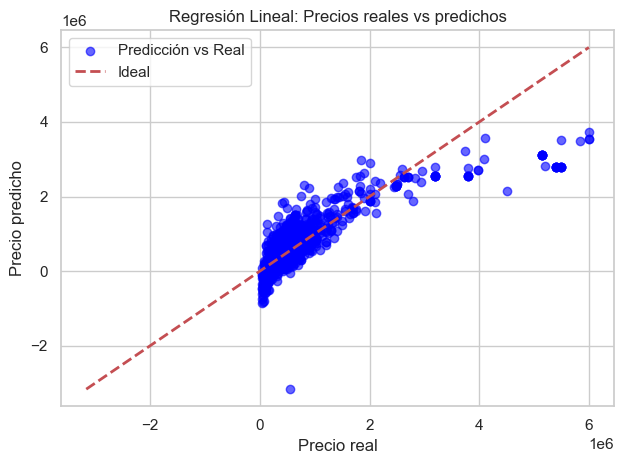

In [152]:
# Métricas
print("REGRESIÓN LINEAL:")
print(f"Coeficiente: {lin.coef_[0]:.3f}")   
print(f"Intercepto: {lin.intercept_:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_lin)):.3f}")
print(f"R²: {r2_score(y_test, pred_lin):.3f}\n")
# Visualización
plt.scatter(y_test, pred_lin, color='blue', alpha=0.6, label='Predicción vs Real')
lims = [min(y_test.min(), pred_lin.min()), max(y_test.max(), pred_lin.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideal')
plt.title('Regresión Lineal: Precios reales vs predichos')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.tight_layout()
plt.show()

In [153]:
# Modelo 2: Árbol de Decisión
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

resultados_tree = pd.DataFrame({
    'Real': y_test,
    'Predicho': pred_tree
})
resultados_tree['Diferencia'] = resultados_tree['Real'] - resultados_tree['Predicho']
resultados_tree

,Real,Predicho,Diferencia
3641,501000,650000.0,-149000.0
5531,440000,510000.0,-70000.0
3524,140000,168000.0,-28000.0
7478,476999,415000.0,61999.0
3455,620000,620000.0,0.0
...,...,...,...
1317,330000,400000.0,-70000.0
622,229999,229999.0,0.0
1419,144000,170000.0,-26000.0
4287,2711000,2678750.0,32250.0


ARBOL DE DECISIÓN:
RMSE: 155465.425
R²: 0.965



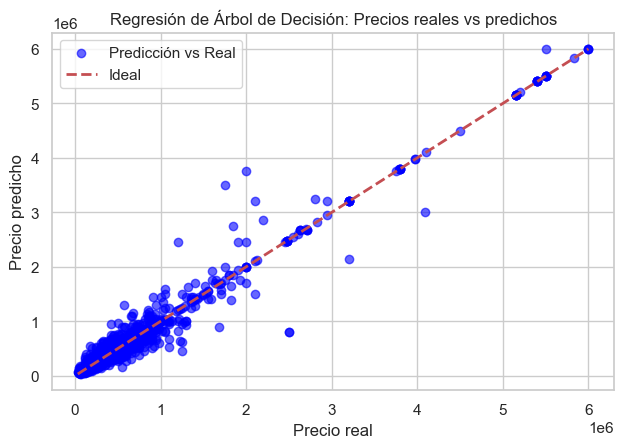

In [154]:
# Métricas
print("ARBOL DE DECISIÓN:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_tree)):.3f}")
print(f"R²: {r2_score(y_test, pred_tree):.3f}\n")
# Visualización
plt.scatter(y_test, pred_tree, color='blue', alpha=0.6, label='Predicción vs Real')
lims = [min(y_test.min(), pred_tree.min()), max(y_test.max(), pred_tree.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideal')
plt.title('Regresión de Árbol de Decisión: Precios reales vs predichos')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.tight_layout()
plt.show()

In [155]:
# Modelo 3: Random Forest
forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
pred_forest = forest.predict(X_test)

resultados_forest = pd.DataFrame({
    'Real': y_test,
    'Predicho': pred_forest
})
resultados_forest['Diferencia'] = resultados_forest['Real'] - resultados_forest['Predicho']
print(resultados_forest)

         Real      Predicho     Diferencia
3641   501000  5.648699e+05  -63869.950000
5531   440000  5.186533e+05  -78653.323333
3524   140000  1.648000e+05  -24799.960000
7478   476999  3.385000e+05  138499.010000
3455   620000  5.871786e+05   32821.448571
...       ...           ...            ...
1317   330000  3.639938e+05  -33993.750000
622    229999  2.510494e+05  -21050.420000
1419   144000  2.129599e+05  -68959.890000
4287  2711000  2.678422e+06   32577.555097
7820   680000  5.629650e+05  117035.000000

[1582 rows x 3 columns]


RANDOM FOREST:
RMSE: 106565.267
R²: 0.984



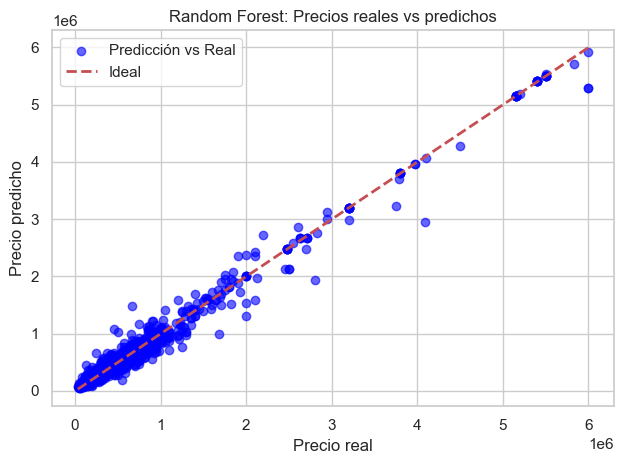

In [156]:
# Métricas
print("RANDOM FOREST:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_forest)):.3f}")
print(f"R²: {r2_score(y_test, pred_forest):.3f}\n")
# Visualización
plt.scatter(y_test, pred_forest, color='blue', alpha=0.6, label='Predicción vs Real')
lims = [min(y_test.min(), pred_forest.min()), max(y_test.max(), pred_forest.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideal')
plt.title('Random Forest: Precios reales vs predichos')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [157]:
# Cálculo y comparación del coeficiente de determinación (R2 Score)
# TIP: Calculen el R2 para las predicciones de los tres modelos. 
# Generen un gráfico de barras (sns.barplot) que compare visualmente qué modelo obtuvo el puntaje más alto.

In [158]:
resultados = {}
for nombre, pred in [("Regresión Lineal", pred_lin),
                     ("Árbol de Decisión", pred_tree),
                     ("Random Forest", pred_forest)]:
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    resultados[nombre] = r2
    print(f"{nombre:20s} ->  R2 = {r2:.3f}   |   RMSE = {rmse:,.0f}")


Regresión Lineal     ->  R2 = 0.695   |   RMSE = 460,216
Árbol de Decisión    ->  R2 = 0.965   |   RMSE = 155,465
Random Forest        ->  R2 = 0.984   |   RMSE = 106,565


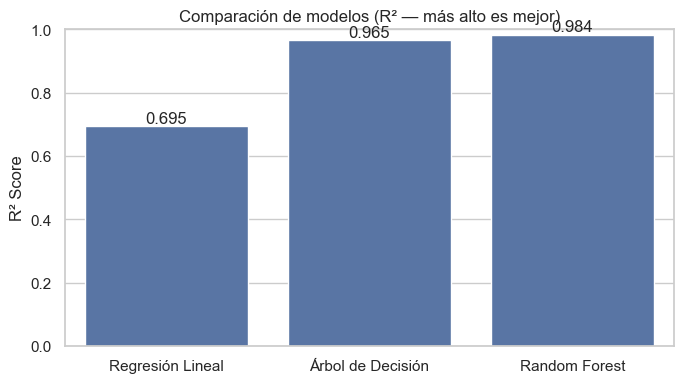

In [159]:
# Gráfico de barras comparando el R2
plt.figure(figsize=(7, 4))
sns.barplot(x=list(resultados.keys()), y=list(resultados.values()))
plt.ylabel("R² Score")
plt.title("Comparación de modelos (R² — más alto es mejor)")
plt.ylim(0, 1)
for i, v in enumerate(resultados.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


In [160]:
# Gráfica de Valores Reales vs. Valores Predichos
# TIP: Creen un gráfico de dispersión (plt.scatter) para cada modelo.
# - Eje X: y_test (Valores reales)
# - Eje Y: Predicciones del modelo
# Dibujen una línea diagonal roja de referencia. Los puntos más cercanos a la línea representan predicciones más exactas.

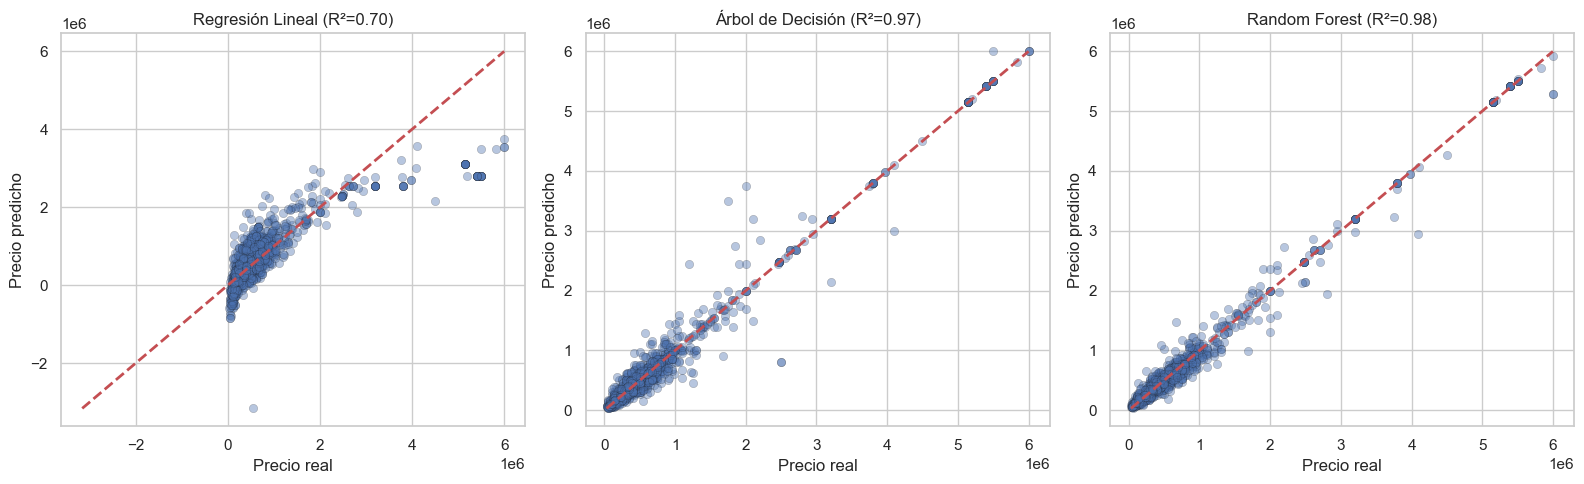

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
modelos = [("Regresión Lineal", pred_lin),
           ("Árbol de Decisión", pred_tree),
           ("Random Forest", pred_forest)]

for ax, (nombre, pred) in zip(axes, modelos):
    ax.scatter(y_test, pred, alpha=0.4, edgecolor="k", linewidth=0.3)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2)   # línea de predicción perfecta
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_title(f"{nombre} (R²={r2_score(y_test, pred):.2f})")

plt.tight_layout()
plt.show()


## 6. Conclusiones — ¿qué aprendimos?

- El **Random Forest** suele ganar aquí: al promediar muchos árboles captura relaciones no lineales (depreciación por año, kilometraje, etc.) sin sobreajustar tanto como un árbol solo.
- La **Regresión Lineal** da una base honesta y muy interpretable, pero pierde frente a los modelos de árboles porque el precio de los autos no se comporta de forma puramente lineal.
- El **Árbol de Decisión** individual suele quedar en medio: flexible, pero más propenso a sobreajustar.